# 03 — Chest X-ray Fine-Tuning Candidate (DenseNet121, Keras) — SUPERSEDED

> ### Superseded exploratory experiment — not used for reported results
>
> This notebook is a **TensorFlow/Keras** experiment kept for the record. It produced
> **none** of the results reported in the app or the report. Every reported X-ray
> result comes from the **PyTorch** pipeline in `src/classification/`, with artifacts
> under `outputs/classification/<run>/` and the authoritative per-run configuration in
> `outputs/classification/<run>/config_used.yaml`. See `docs/REPRODUCIBILITY.md`.
>
> Keras artifacts written here (`outputs/models/xray/*.keras`) are likewise not the
> source of any reported metric.


**Academic prototype only.** This notebook builds **one** controlled fine-tuning
candidate and compares it with the frozen-backbone baseline. It is **not** a
clinical diagnostic system and must **never** be used for patient care.

## Scope

- Start from `outputs/models/xray/xray_densenet121_baseline.keras`.
- Train / validate only on patient-safe `train_clean.csv` / `valid_clean.csv`.
- Do **not** touch `test.csv`, raw data, clean CSVs, or baseline artefacts.

## Design choices

| Choice | Reason |
|---|---|
| **Lower LR (`1e-5`)** | The backbone already has useful ImageNet features; a small step size adapts upper layers without destroying them. |
| **Unfreeze only upper ~20%** | Early DenseNet blocks learn generic edges/textures; later blocks are more task-specific and safer to adapt with limited medical data. |
| **Keep BatchNorm frozen** | Updating BN running stats on a small X-ray batch can destabilise features; freeze BN during fine-tuning. |
| **Modest augmentation** | Medical images have orientation meaning; we allow tiny rotation/translation/contrast only — **no flips**. |
| **Test untouched** | Final evaluation must stay once-only after model selection. |

## 0. Setup, seeds, and paths

In [1]:
from pathlib import Path
import os
import random
import time

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

IMAGE_SIZE = 320
BATCH_SIZE = 8
EPOCHS = 8
LEARNING_RATE = 1e-5
MIN_STABLE_POS = 5  # validation positives required for "stable" AUROC

RAW_IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "xray" / "nih" / "images-small"
TRAIN_CSV = PROJECT_ROOT / "data" / "processed" / "xray" / "train_clean.csv"
VALID_CSV = PROJECT_ROOT / "data" / "processed" / "xray" / "valid_clean.csv"

BASELINE_MODEL = PROJECT_ROOT / "outputs" / "models" / "xray" / "xray_densenet121_baseline.keras"
BASELINE_METRICS = PROJECT_ROOT / "outputs" / "metrics" / "xray" / "baseline_valid_auroc.csv"

FT_MODEL = PROJECT_ROOT / "outputs" / "models" / "xray" / "xray_densenet121_finetuned.keras"
FT_METRICS = PROJECT_ROOT / "outputs" / "metrics" / "xray" / "finetuned_valid_auroc.csv"
COMPARE_CSV = PROJECT_ROOT / "outputs" / "metrics" / "xray" / "baseline_vs_finetuned_comparison.csv"
FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "xray" / "finetuned_training_curves.png"

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass", "Nodule",
    "Pleural_Thickening", "Pneumonia", "Pneumothorax",
]

print("Project root:", PROJECT_ROOT)
print(f"BATCH_SIZE={BATCH_SIZE}  IMAGE_SIZE={IMAGE_SIZE}  EPOCHS={EPOCHS}  LR={LEARNING_RATE}  SEED={SEED}")

Project root: D:\AI Engineering\medicaldiagnostic_finalproject
BATCH_SIZE=8  IMAGE_SIZE=320  EPOCHS=8  LR=1e-05  SEED=42


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

np.random.seed(SEED)

try:
    import tensorflow as tf
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing required package: tensorflow. Stopping without installing."
    ) from exc

tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus if gpus else "None detected (CPU)")

for path, label in [
    (TRAIN_CSV, "train_clean.csv"),
    (VALID_CSV, "valid_clean.csv"),
    (BASELINE_MODEL, "baseline model"),
    (BASELINE_METRICS, "baseline metrics"),
]:
    if not path.exists():
        raise FileNotFoundError(f"Required {label} not found: {path}")
print("[ok] Required inputs present (baseline artefacts will not be overwritten)")

TensorFlow: 2.19.1
GPU devices: None detected (CPU)
[ok] Required inputs present (baseline artefacts will not be overwritten)


## 1. Load clean splits and safety checks

Same patient-safe splits as the baseline. Official test set is not loaded.

In [3]:
def load_clean_csv(path: Path, name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = ["Image", "PatientId"] + LABEL_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    return df[required].copy()


train_df = load_clean_csv(TRAIN_CSV, "train_clean.csv")
valid_df = load_clean_csv(VALID_CSV, "valid_clean.csv")

available_images = {
    p.name
    for p in RAW_IMAGE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower() == ".png"
    and not p.name.startswith("._")
    and p.name != ".DS_Store"
}


def assert_images_exist(df: pd.DataFrame, name: str) -> None:
    missing = sorted(set(df["Image"]) - available_images)
    if missing:
        raise FileNotFoundError(f"{name}: {len(missing)} missing images, e.g. {missing[:5]}")
    print(f"[ok] {name}: all {len(df)} images exist")


assert_images_exist(train_df, "train_clean")
assert_images_exist(valid_df, "valid_clean")

overlap = set(train_df["PatientId"]) & set(valid_df["PatientId"])
if overlap:
    raise RuntimeError(f"Patient leakage: {len(overlap)} shared PatientIds")
print("[ok] No PatientId overlap between train_clean and valid_clean")

train_pos = train_df[LABEL_COLS].sum().astype(int)
zero_pos = [c for c in LABEL_COLS if train_pos[c] == 0]
if zero_pos:
    raise RuntimeError(f"Zero training positives for: {zero_pos}")
print("[ok] All 14 labels have ≥1 training positive")
print(f"train_clean: {len(train_df)} rows | valid_clean: {len(valid_df)} rows")

[ok] train_clean: all 948 images exist
[ok] valid_clean: all 252 images exist
[ok] No PatientId overlap between train_clean and valid_clean
[ok] All 14 labels have ≥1 training positive
train_clean: 948 rows | valid_clean: 252 rows


## 2. Class weights from train_clean only

Same weighted BCE as the baseline:

$$
w^{+}_j = N_j / P_j, \qquad w^{-}_j = P_j / N_j
$$

$$
\mathcal{L}_j = -\big(w^{+}_j y_j \log p_j + w^{-}_j (1-y_j)\log(1-p_j)\big)
$$

In [4]:
y_train = train_df[LABEL_COLS].to_numpy(dtype=np.float32)
y_valid = valid_df[LABEL_COLS].to_numpy(dtype=np.float32)

N = len(train_df)
pos = y_train.sum(axis=0)
neg = N - pos
w_pos = (neg / pos).astype(np.float32)
w_neg = (pos / neg).astype(np.float32)

W_POS = tf.constant(w_pos, dtype=tf.float32)
W_NEG = tf.constant(w_neg, dtype=tf.float32)
EPS = 1e-7


def weighted_binary_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1.0 - EPS)
    loss = -(W_POS * y_true * tf.math.log(y_pred) + W_NEG * (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    return tf.reduce_mean(tf.reduce_mean(loss, axis=-1))


print("[ok] Class weights computed from train_clean only")
display(pd.DataFrame({"positives": pos.astype(int), "w_pos": w_pos, "w_neg": w_neg}, index=LABEL_COLS).round(3))

[ok] Class weights computed from train_clean only


,positives,w_pos,w_neg
Atelectasis,102,8.294000,0.121
Cardiomegaly,17,54.764999,0.018
Consolidation,36,25.333000,0.039
Edema,10,93.800003,0.011
Effusion,132,6.182000,0.162
Emphysema,15,62.200001,0.016
Fibrosis,8,117.500000,0.009
Hernia,2,473.000000,0.002
Infiltration,165,4.745000,0.211
Mass,44,20.545000,0.049


## 3. `tf.data` pipeline with modest train-only augmentation

**Why limited augmentation?** Chest X-rays are standardised projections. Large
geometric changes (especially flips) can create anatomically impossible views.
We only apply small rotation (±7°), translation (≤5%), and mild contrast change.
Validation images are **not** augmented.

In [5]:
preprocess_input = tf.keras.applications.densenet.preprocess_input

# Keras factors: rotation is fraction of 2π → 7° = 7/360 of a full turn
aug_rotate = tf.keras.layers.RandomRotation(7.0 / 360.0, fill_mode="constant", fill_value=0.0)
aug_translate = tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=0.0)
aug_contrast = tf.keras.layers.RandomContrast(0.10)


def augment_image(image: tf.Tensor) -> tf.Tensor:
    image = aug_rotate(image, training=True)
    image = aug_translate(image, training=True)
    image = aug_contrast(image, training=True)
    # No horizontal or vertical flips (medical orientation matters)
    return image


def make_dataset(df: pd.DataFrame, *, shuffle: bool, augment: bool, batch_size: int) -> tf.data.Dataset:
    paths = [str(RAW_IMAGE_DIR / name) for name in df["Image"].tolist()]
    labels = df[LABEL_COLS].to_numpy(dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        image_bytes = tf.io.read_file(path)
        image = tf.io.decode_png(image_bytes, channels=3)  # grayscale → 3ch
        image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
        image = tf.cast(image, tf.float32)
        if augment:
            image = augment_image(image)
        image = preprocess_input(image)  # DenseNet only — no /255
        return image, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True, augment=True, batch_size=BATCH_SIZE)
valid_ds = make_dataset(valid_df, shuffle=False, augment=False, batch_size=BATCH_SIZE)

xb, yb = next(iter(train_ds))
print("Train batch:", xb.shape, xb.dtype, "| labels:", yb.shape)
print("[ok] Train uses modest augmentation; validation has none")

Train batch: (8, 320, 320, 3) <dtype: 'float32'> | labels: (8, 14)
[ok] Train uses modest augmentation; validation has none


## 4. Load baseline and configure partial fine-tuning

- Keep most DenseNet121 layers frozen.
- Unfreeze the **last ~20%** of backbone layers (falls inside the final `conv5` dense block).
- **BatchNormalization stays frozen**.
- Classifier head remains trainable.
- Adam at **`1e-5`** (much lower than the baseline head LR of `1e-3`).

In [6]:
model = tf.keras.models.load_model(BASELINE_MODEL, compile=False)
backbone = model.get_layer("densenet121")

# Enable selective training inside the nested backbone
backbone.trainable = True
n_backbone = len(backbone.layers)
unfreeze_from = int(n_backbone * 0.80)  # last ~20%

n_unfrozen = 0
n_bn_kept_frozen = 0
for i, layer in enumerate(backbone.layers):
    if i < unfreeze_from:
        layer.trainable = False
    else:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            n_bn_kept_frozen += 1
        else:
            layer.trainable = True
            n_unfrozen += 1

# Head layers stay trainable
for name in ["global_average_pooling2d", "dropout", "disease_probs"]:
    if name in {l.name for l in model.layers}:
        model.get_layer(name).trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=weighted_binary_crossentropy,
    metrics=[tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.5)],
)

trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))

print(f"Backbone layers: {n_backbone}")
print(f"Unfreeze from index {unfreeze_from} ({backbone.layers[unfreeze_from].name})")
print(f"Unfrozen non-BN backbone layers: {n_unfrozen}")
print(f"BN layers kept frozen in unfreeze window: {n_bn_kept_frozen}")
print(f"Trainable params: {trainable:,} | Non-trainable: {non_trainable:,}")
print(f"Loaded baseline from: {BASELINE_MODEL.relative_to(PROJECT_ROOT)}")

Backbone layers: 427
Unfreeze from index 341 (conv5_block5_0_bn)
Unfrozen non-BN backbone layers: 61
BN layers kept frozen in unfreeze window: 25
Trainable params: 1,710,094 | Non-trainable: 5,341,760
Loaded baseline from: outputs\models\xray\xray_densenet121_baseline.keras


## 5. Fine-tune (validation = valid_clean only)

EarlyStopping on `val_loss`, patience=2, `restore_best_weights=True`.
Maximum 8 epochs. Binary accuracy remains a secondary, easily misleading metric.

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

t0 = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1,
)
train_seconds = time.perf_counter() - t0

hist = pd.DataFrame(history.history)
hist.insert(0, "epoch", np.arange(1, len(hist) + 1))
display(hist)

best_epoch = int(np.argmin(hist["val_loss"].to_numpy()) + 1)
best_val_loss = float(hist["val_loss"].min())
print(f"Training time: {train_seconds/60:.2f} min ({train_seconds:.1f} s)")
print(f"Best val_loss: {best_val_loss:.4f} (epoch {best_epoch})")

Epoch 1/8


D:\AI Engineering\medicaldiagnostic_finalproject\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/119 ━━━━━━━━━━━━━━━━━━━━ 27:03 14s/step - binary_accuracy: 0.0536 - loss: 0.1549

  2/119 ━━━━━━━━━━━━━━━━━━━━ 33s 290ms/step - binary_accuracy: 0.0714 - loss: 0.1456

  3/119 ━━━━━━━━━━━━━━━━━━━━ 33s 292ms/step - binary_accuracy: 0.0685 - loss: 0.1438

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 649ms/step - binary_accuracy: 0.0604 - loss: 0.1630 - val_binary_accuracy: 0.0431 - val_loss: 0.1677


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 4.


,epoch,binary_accuracy,loss,val_binary_accuracy,val_loss
0,1,0.058921,0.199832,0.043084,0.170877
1,2,0.056209,0.167707,0.043084,0.169800
2,3,0.057414,0.166809,0.043084,0.168375
3,4,0.058168,0.165763,0.043084,0.167505
4,5,0.059750,0.165373,0.043084,0.168345
5,6,0.060428,0.162992,0.043084,0.167738


Training time: 10.64 min (638.6 s)
Best val_loss: 0.1675 (epoch 4)


## 6. Validation AUROC for the fine-tuned candidate

- Per-class AUROC when validation has both classes.
- **All-class macro AUROC**: mean over defined classes.
- **Stable macro AUROC**: mean over classes with **≥ 5** validation positives
  (classes below that threshold are flagged as **unstable**).
- No threshold tuning. No test set.

In [8]:
def evaluate_auroc(y_true: np.ndarray, y_prob: np.ndarray) -> pd.DataFrame:
    rows = []
    for i, disease in enumerate(LABEL_COLS):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        n_pos = int(yt.sum())
        n_neg = int(len(yt) - n_pos)
        if n_pos == 0 or n_neg == 0:
            auc = np.nan
            stability = "undefined"
            note = "undefined (need both classes)"
        else:
            auc = float(roc_auc_score(yt, yp))
            if n_pos < MIN_STABLE_POS:
                stability = "unstable"
                note = f"unstable (<{MIN_STABLE_POS} val positives)"
            else:
                stability = "stable"
                note = "ok"
        rows.append({
            "disease": disease,
            "valid_positives": n_pos,
            "valid_negatives": n_neg,
            "auroc": auc,
            "stability": stability,
            "note": note,
        })
    return pd.DataFrame(rows)


y_prob_ft = model.predict(valid_ds, verbose=0)
ft_auroc = evaluate_auroc(y_valid, y_prob_ft)

defined = ft_auroc["auroc"].dropna()
stable = ft_auroc.loc[ft_auroc["stability"] == "stable", "auroc"]
macro_all = float(defined.mean()) if len(defined) else float("nan")
macro_stable = float(stable.mean()) if len(stable) else float("nan")

display(ft_auroc)
print(f"All-class macro AUROC ({len(defined)} classes): {macro_all:.4f}")
print(f"Stable macro AUROC (≥{MIN_STABLE_POS} val positives, {len(stable)} classes): {macro_stable:.4f}")
print("Unstable classes:", ft_auroc.loc[ft_auroc["stability"] == "unstable", "disease"].tolist())

,disease,valid_positives,valid_negatives,auroc,stability,note
0,Atelectasis,23,229,0.624264,stable,ok
1,Cardiomegaly,7,245,0.553353,stable,ok
2,Consolidation,4,248,0.219758,unstable,unstable (<5 val positives)
3,Edema,8,244,0.367828,stable,ok
4,Effusion,23,229,0.735713,stable,ok
5,Emphysema,1,251,1.000000,unstable,unstable (<5 val positives)
6,Fibrosis,7,245,0.844315,stable,ok
7,Hernia,1,251,1.000000,unstable,unstable (<5 val positives)
8,Infiltration,39,213,0.548212,stable,ok
9,Mass,10,242,0.470248,stable,ok


All-class macro AUROC (14 classes): 0.6137
Stable macro AUROC (≥5 val positives, 10 classes): 0.5922
Unstable classes: ['Consolidation', 'Emphysema', 'Hernia', 'Pneumonia']


## 7. Compare with frozen baseline (primary = stable macro AUROC)

Baseline metrics are **read** from disk; the baseline model file is never overwritten.
We also score the saved baseline on the same validation loader to obtain a
comparable `val_loss` under the same weighted BCE.

In [9]:
baseline_csv = pd.read_csv(BASELINE_METRICS)
baseline_per = baseline_csv[baseline_csv["disease"] != "MACRO"].copy()

# Align baseline AUROCs with stability flags from validation counts
stability_map = ft_auroc.set_index("disease")["stability"].to_dict()
pos_map = ft_auroc.set_index("disease")["valid_positives"].to_dict()
baseline_per["stability"] = baseline_per["disease"].map(stability_map)
baseline_per["valid_positives"] = baseline_per["disease"].map(pos_map)

base_defined = baseline_per["auroc"].dropna()
base_stable = baseline_per.loc[baseline_per["stability"] == "stable", "auroc"].dropna()
base_macro_all = float(base_defined.mean()) if len(base_defined) else float("nan")
base_macro_stable = float(base_stable.mean()) if len(base_stable) else float("nan")

# Baseline val_loss on the same valid_ds / loss (read-only load)
baseline_model = tf.keras.models.load_model(BASELINE_MODEL, compile=False)
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=weighted_binary_crossentropy)
base_eval = baseline_model.evaluate(valid_ds, verbose=0, return_dict=True)
baseline_val_loss = float(base_eval["loss"])

print(f"Baseline val_loss (re-eval): {baseline_val_loss:.4f}")
print(f"Fine-tuned best val_loss   : {best_val_loss:.4f}")
print(f"Baseline stable macro AUROC: {base_macro_stable:.4f}")
print(f"Fine-tuned stable macro AUROC: {macro_stable:.4f}")

# Per-class comparison table
cmp = baseline_per[["disease", "valid_positives", "stability", "auroc"]].rename(
    columns={"auroc": "baseline_auroc"}
).merge(
    ft_auroc[["disease", "auroc"]].rename(columns={"auroc": "finetuned_auroc"}),
    on="disease",
    how="outer",
)
cmp["delta_auroc"] = cmp["finetuned_auroc"] - cmp["baseline_auroc"]
display(cmp)

# Summary rows for decision
summary_rows = pd.DataFrame([
    {
        "metric": "macro_auroc_all_classes",
        "baseline": base_macro_all,
        "finetuned": macro_all,
        "delta_ft_minus_base": macro_all - base_macro_all,
        "role": "secondary_descriptor",
    },
    {
        "metric": "stable_macro_auroc",
        "baseline": base_macro_stable,
        "finetuned": macro_stable,
        "delta_ft_minus_base": macro_stable - base_macro_stable,
        "role": "primary_comparison",
    },
    {
        "metric": "val_loss",
        "baseline": baseline_val_loss,
        "finetuned": best_val_loss,
        "delta_ft_minus_base": best_val_loss - baseline_val_loss,
        "role": "secondary_comparison",
    },
])
display(summary_rows)

# Decision rule: primary = stable macro AUROC (higher better);
# secondary = val_loss (lower better) if primary is essentially tied.
primary_eps = 1e-4
if macro_stable > base_macro_stable + primary_eps:
    recommendation = "select_finetuned"
    reason = "Higher stable macro AUROC on patient-safe validation."
elif macro_stable < base_macro_stable - primary_eps:
    recommendation = "retain_baseline"
    reason = "Baseline has higher stable macro AUROC."
else:
    # tie on primary → prefer lower val_loss
    if best_val_loss < baseline_val_loss - primary_eps:
        recommendation = "select_finetuned"
        reason = "Stable macro AUROC tied; fine-tuned has lower val_loss."
    else:
        recommendation = "retain_baseline"
        reason = "Stable macro AUROC tied; baseline has equal/better val_loss (prefer simpler frozen model)."

print("\n=== MODEL SELECTION RECOMMENDATION ===")
print("Recommendation:", recommendation)
print("Reason:", reason)
print("Note: baseline artefacts are kept on disk regardless of this choice.")

Baseline val_loss (re-eval): 0.1707
Fine-tuned best val_loss   : 0.1675
Baseline stable macro AUROC: 0.5593
Fine-tuned stable macro AUROC: 0.5922


,disease,valid_positives,stability,baseline_auroc,finetuned_auroc,delta_auroc
0,Atelectasis,23,stable,0.593317,0.624264,0.030947
1,Cardiomegaly,7,stable,0.419825,0.553353,0.133528
2,Consolidation,4,unstable,0.238911,0.219758,-0.019153
3,Edema,8,stable,0.319928,0.367828,0.047900
4,Effusion,23,stable,0.723372,0.735713,0.012341
5,Emphysema,1,unstable,0.992032,1.000000,0.007968
6,Fibrosis,7,stable,0.831487,0.844315,0.012828
7,Hernia,1,unstable,0.988048,1.000000,0.011952
8,Infiltration,39,stable,0.537258,0.548212,0.010955
9,Mass,10,stable,0.418595,0.470248,0.051653


,metric,baseline,finetuned,delta_ft_minus_base,role
0,macro_auroc_all_classes,0.580001,0.613731,0.033730,secondary_descriptor
1,stable_macro_auroc,0.559302,0.592247,0.032945,primary_comparison
2,val_loss,0.170710,0.167505,-0.003205,secondary_comparison



=== MODEL SELECTION RECOMMENDATION ===
Recommendation: select_finetuned
Reason: Higher stable macro AUROC on patient-safe validation.
Note: baseline artefacts are kept on disk regardless of this choice.


## 8. Save fine-tuned artefacts (baseline untouched)

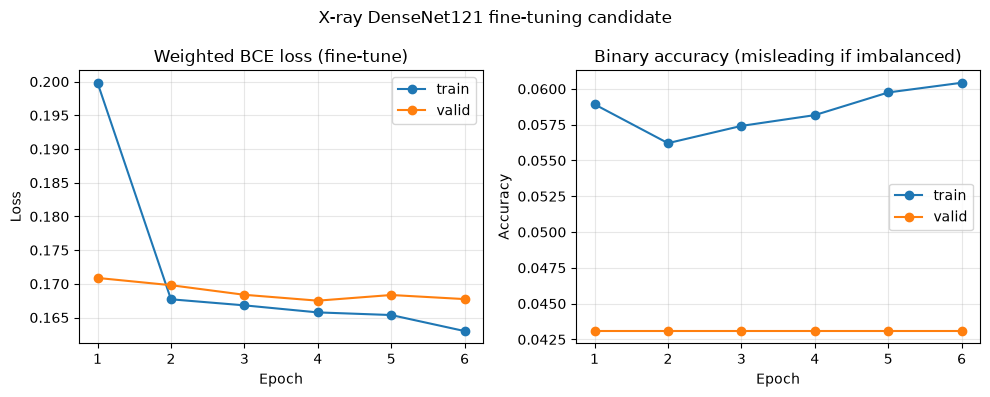

Saved:
 - outputs\figures\xray\finetuned_training_curves.png
 - outputs\metrics\xray\finetuned_valid_auroc.csv
 - outputs\metrics\xray\baseline_vs_finetuned_comparison.csv
 - outputs\models\xray\xray_densenet121_finetuned.keras
Baseline preserved: outputs\models\xray\xray_densenet121_baseline.keras exists= True


In [10]:
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
FT_METRICS.parent.mkdir(parents=True, exist_ok=True)
FT_MODEL.parent.mkdir(parents=True, exist_ok=True)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_axis = hist["epoch"]
axes[0].plot(epochs_axis, hist["loss"], marker="o", label="train")
axes[0].plot(epochs_axis, hist["val_loss"], marker="o", label="valid")
axes[0].set_title("Weighted BCE loss (fine-tune)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, hist["binary_accuracy"], marker="o", label="train")
axes[1].plot(epochs_axis, hist["val_binary_accuracy"], marker="o", label="valid")
axes[1].set_title("Binary accuracy (misleading if imbalanced)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("X-ray DenseNet121 fine-tuning candidate", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

# Fine-tuned AUROC table (+ summary rows)
ft_save = ft_auroc.copy()
ft_save.loc[len(ft_save)] = {
    "disease": "MACRO_ALL",
    "valid_positives": np.nan,
    "valid_negatives": np.nan,
    "auroc": macro_all,
    "stability": "summary",
    "note": f"mean of {len(defined)} defined per-class AUROCs",
}
ft_save.loc[len(ft_save)] = {
    "disease": "MACRO_STABLE",
    "valid_positives": np.nan,
    "valid_negatives": np.nan,
    "auroc": macro_stable,
    "stability": "summary",
    "note": f"mean of {len(stable)} classes with ≥{MIN_STABLE_POS} val positives",
}
ft_save.to_csv(FT_METRICS, index=False)

# Comparison CSV: per-class + summary + recommendation
cmp_save = cmp.copy()
cmp_save["recommendation"] = ""
summary_export = summary_rows.rename(columns={"metric": "disease", "baseline": "baseline_auroc", "finetuned": "finetuned_auroc", "delta_ft_minus_base": "delta_auroc"})
summary_export["valid_positives"] = np.nan
summary_export["stability"] = summary_export["role"]
summary_export["recommendation"] = ""
summary_export = summary_export[["disease", "valid_positives", "stability", "baseline_auroc", "finetuned_auroc", "delta_auroc", "recommendation"]]

decision_row = pd.DataFrame([{
    "disease": "DECISION",
    "valid_positives": np.nan,
    "stability": "recommendation",
    "baseline_auroc": base_macro_stable,
    "finetuned_auroc": macro_stable,
    "delta_auroc": macro_stable - base_macro_stable,
    "recommendation": f"{recommendation} | {reason}",
}])

comparison_out = pd.concat([cmp_save, summary_export, decision_row], ignore_index=True)
comparison_out.to_csv(COMPARE_CSV, index=False)

# Save fine-tuned model only (never overwrite baseline)
model.save(FT_MODEL)

print("Saved:")
print(" -", FIG_PATH.relative_to(PROJECT_ROOT))
print(" -", FT_METRICS.relative_to(PROJECT_ROOT))
print(" -", COMPARE_CSV.relative_to(PROJECT_ROOT))
print(" -", FT_MODEL.relative_to(PROJECT_ROOT))
print("Baseline preserved:", BASELINE_MODEL.relative_to(PROJECT_ROOT), "exists=", BASELINE_MODEL.exists())

## 9. Conclusion

- Fine-tuning used a **low learning rate** and **upper-layer-only** updates so
  pretrained features are adapted gently.
- Augmentation stayed **X-ray-safe** (no flips).
- Selection used **stable macro AUROC** first, then **val_loss**.
- The **official test set remains untouched** until final evaluation.
- The **baseline model and metrics remain on disk** even if the candidate wins.

In [11]:
print("=== Fine-tuning run summary ===")
print("TensorFlow :", tf.__version__)
print("Device     :", "GPU" if gpus else "CPU")
print("Epochs run :", len(hist))
print("Train time :", f"{train_seconds:.1f}s")
print("Best val_loss:", f"{best_val_loss:.4f}", f"(epoch {best_epoch})")
print("Macro AUROC (all):", f"{macro_all:.4f}")
print("Macro AUROC (stable):", f"{macro_stable:.4f}")
print("Recommendation:", recommendation)
print("Reason:", reason)

=== Fine-tuning run summary ===
TensorFlow : 2.19.1
Device     : CPU
Epochs run : 6
Train time : 638.6s
Best val_loss: 0.1675 (epoch 4)
Macro AUROC (all): 0.6137
Macro AUROC (stable): 0.5922
Recommendation: select_finetuned
Reason: Higher stable macro AUROC on patient-safe validation.
